In [1]:
import pandas as pd

dataframe = pd.read_csv("../data/house_data.csv")
dataframe.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [2]:
dataframe.shape

(21613, 21)

In [3]:
# Sin valores faltantes

int(dataframe.isna().sum().sum())

0

In [4]:
# Las 7 variables que usa el modelo (las del formulario web) y el precio

FEATURES = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront", "condition"]

dataframe[["price"] + FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,21613.0,540088.14,367127.20,75000.0,321950.00,450000.00,645000.0,7700000.0
bedrooms,21613.0,3.37,0.93,0.0,3.00,3.00,4.0,33.0
bathrooms,21613.0,2.11,0.77,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,2079.90,918.44,290.0,1427.00,1910.00,2550.0,13540.0
sqft_lot,21613.0,15106.97,41420.51,520.0,5040.00,7618.00,10688.0,1651359.0
floors,21613.0,1.49,0.54,1.0,1.00,1.50,2.0,3.5
waterfront,21613.0,0.01,0.09,0.0,0.00,0.00,0.0,1.0
condition,21613.0,3.41,0.65,1.0,3.00,3.00,4.0,5.0


In [5]:
# El precio tiene cola larga a la derecha: la media queda muy por encima
# de la mediana

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(dataframe["price"] / 1e6, bins=80)
axes[0].set_xlabel("Precio (millones de USD)")
axes[1].hist(np.log10(dataframe["price"]), bins=80)
axes[1].set_xlabel("log10(precio)")
plt.show()

<Figure size 1000x350 with 2 Axes>

In [6]:
# Correlacion de cada variable con el precio: sqft_living es la mas fuerte

dataframe[FEATURES].corrwith(dataframe["price"]).sort_values(ascending=False).round(3)

sqft_living    0.702
bathrooms      0.525
bedrooms       0.308
waterfront     0.266
floors         0.257
sqft_lot       0.090
condition      0.036
dtype: float64

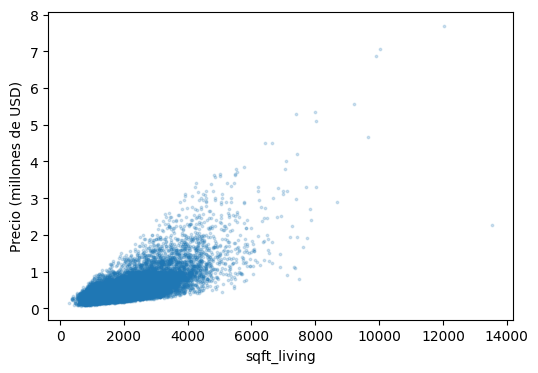

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(dataframe["sqft_living"], dataframe["price"] / 1e6, s=3, alpha=0.2)
ax.set_xlabel("sqft_living")
ax.set_ylabel("Precio (millones de USD)")
plt.show()

In [8]:
# Precio mediano por frente al agua y por condicion

print(dataframe.groupby("waterfront")["price"].agg(["size", "median"]))
print()
print(dataframe.groupby("condition")["price"].agg(["size", "median"]))

             size     median
waterfront                  
0           21450   450000.0
1             163  1400000.0

            size    median
condition                 
1             30  262500.0
2            172  279000.0
3          14031  450000.0
4           5679  440000.0
5           1701  526000.0


In [9]:
# Valores atipicos: una vivienda con 33 habitaciones y 1620 sqft
# (probablemente un error de digitacion de 3)

dataframe.loc[dataframe["bedrooms"] >= 11, ["price", "bedrooms", "bathrooms", "sqft_living"]]

,price,bedrooms,bathrooms,sqft_living
8757,520000.0,11,3.00,3000
15870,640000.0,33,1.75,1620


In [10]:
# Entrenamiento y evaluacion (ver train_model.py). Una regresion lineal
# con estas 7 variables explica ~56% de la varianza del precio en la
# particion de prueba: sirve para ilustrar el despliegue, no como tasador.

import train_model

modelo = train_model.main()

pd.Series(modelo.coef_, index=FEATURES).round(0)

r2_train: 0.544
r2_test: 0.566
mae_test: 168,343.179
Modelo guardado en C:\Users\danie\dev\Analitica Predictiva\std-daniel-gonzalez-henao\PRE_07_deployment\submission\house_predictor.pkl


bedrooms       -55387.0
bathrooms       10326.0
sqft_living       300.0
sqft_lot           -0.0
floors          16177.0
waterfront     784526.0
condition       50797.0
dtype: float64